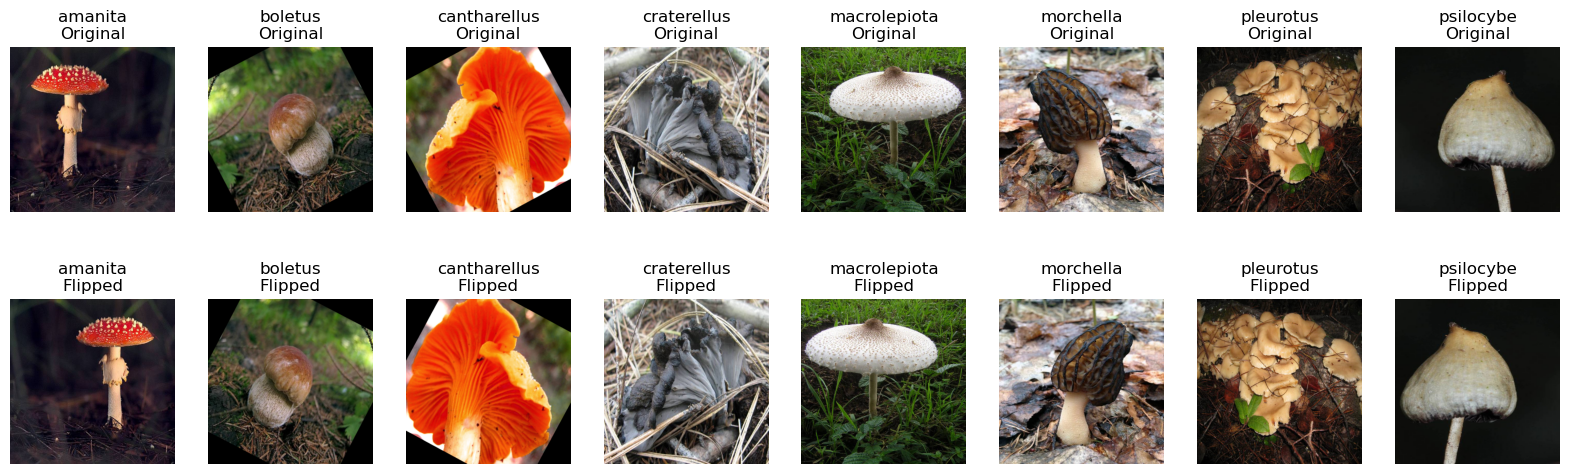

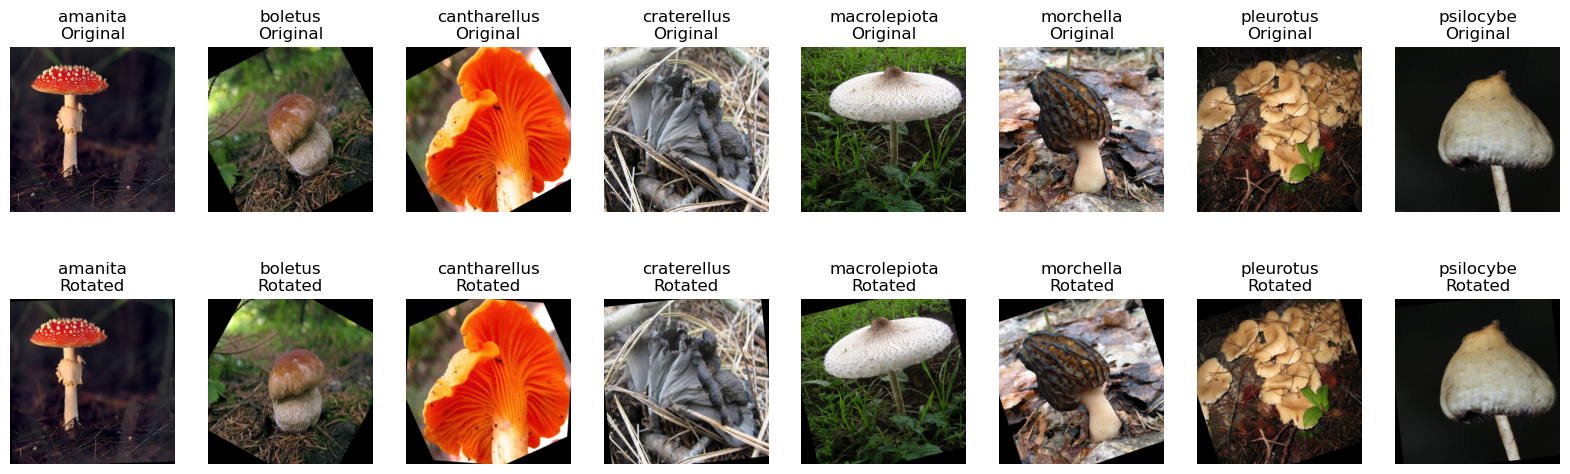

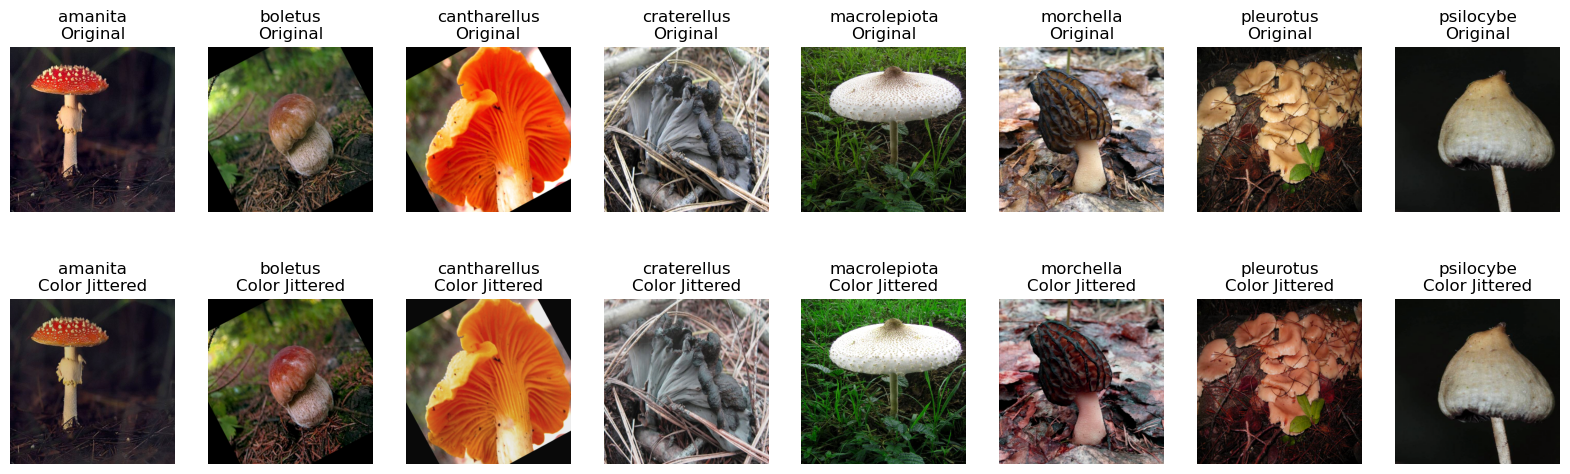

In [26]:
import os
import cv2
import albumentations as A
import matplotlib.pyplot as plt

# Paths
dataset_path =  r'D:\Project\data_kaggle\aug\train_split' 

# Define augmentation techniques
augmentations = {
    "Flipped": A.HorizontalFlip(p=1.0),
    "Rotated": A.Rotate(limit=30, p=1.0),
    "Color Jittered": A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=1.0)
}

# Get 1 image from each of the 8 classes
class_images = {}
for class_name in sorted(os.listdir(dataset_path))[:8]:  # Pick first 8 classes
    class_path = os.path.join(dataset_path, class_name)
    images = [img for img in os.listdir(class_path) if img.endswith(('.jpg', '.png', '.jpeg'))]
    
    if images:
        class_images[class_name] = os.path.join(class_path, images[0])  # Pick first image

# Loop through each augmentation technique separately
for aug_name, aug_transform in augmentations.items():
    fig, axes = plt.subplots(2, 8, figsize=(20, 6))  # 2 rows, 8 columns
    
    for i, (class_name, img_path) in enumerate(class_images.items()):
        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply augmentation
        augmented = aug_transform(image=image)["image"]

        # Show original (top row)
        axes[0, i].imshow(image)
        axes[0, i].set_title(f"{class_name}\nOriginal")
        axes[0, i].axis("off")

        # Show augmented (bottom row)
        axes[1, i].imshow(augmented)
        axes[1, i].set_title(f"{class_name}\n{aug_name}")
        axes[1, i].axis("off")

    plt.show()


In [ ]:
dataset_path =  r'D:\Project\data_kaggle\aug\train_split' 